<a href="https://colab.research.google.com/github/niran-j2005/assesment/blob/main/niranjan_supervisedlearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
filepath='/content/Training_data.csv'
df=pd.read_csv(filepath)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.shape

(5634, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.duplicated().sum()

np.int64(0)

histplot for checking distribution

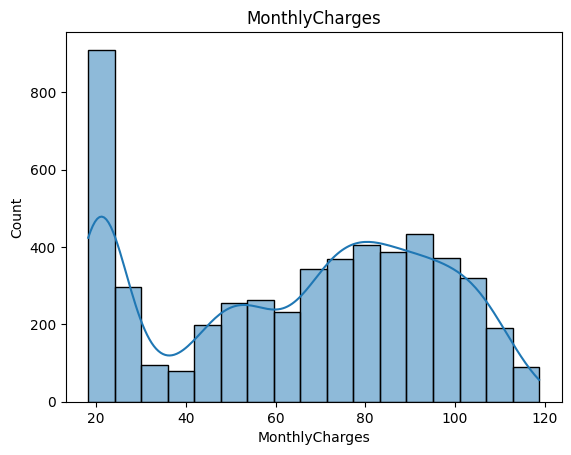

In [ ]:
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        sns.histplot(df[col], kde=True)
        plt.title(col)
        plt.show()

In [ ]:
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())

### Handling Missing Values for `TotalCharges`

First, I'll convert the `TotalCharges` column to a numeric type. Since `df.head()` showed that `TotalCharges` contains numerical values, it's likely that some non-numeric entries exist, which cause it to be an `object` type. I'll use `pd.to_numeric` with `errors='coerce'` to turn any non-convertible values into `NaN`. Then, similar to `MonthlyCharges`, I'll fill the `NaN` values with the median of the `TotalCharges` column.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

### Handling Missing Values for Categorical Columns

For categorical columns like `gender` and `OnlineSecurity`, it's common practice to fill missing values with the mode (the most frequent value). This approach helps maintain the distribution of the column while ensuring there are no `NaN` entries that could cause issues in further analysis or model training.

In [ ]:
for col in ['gender', 'OnlineSecurity']:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

### Verifying Remaining Missing Values

To confirm that all identified missing values have been addressed, I'll check the sum of null values across all columns again.

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#detecting outliers

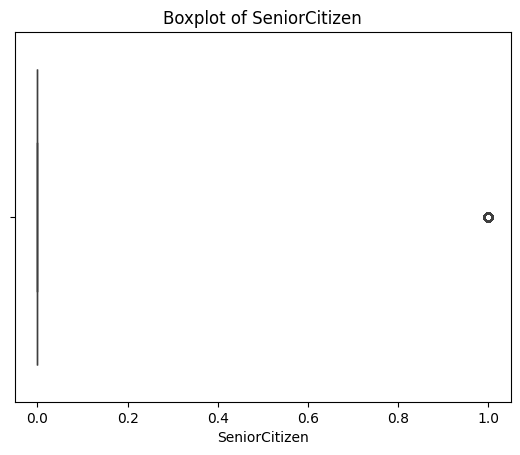

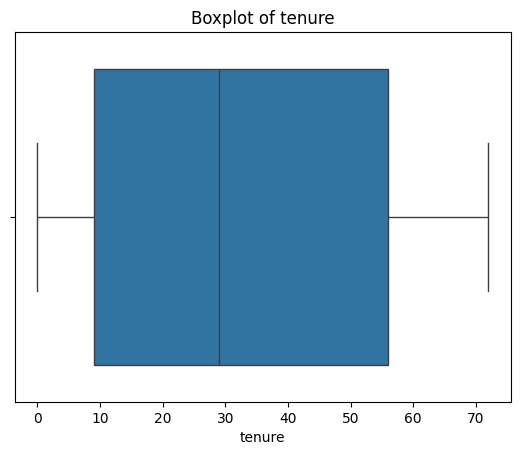

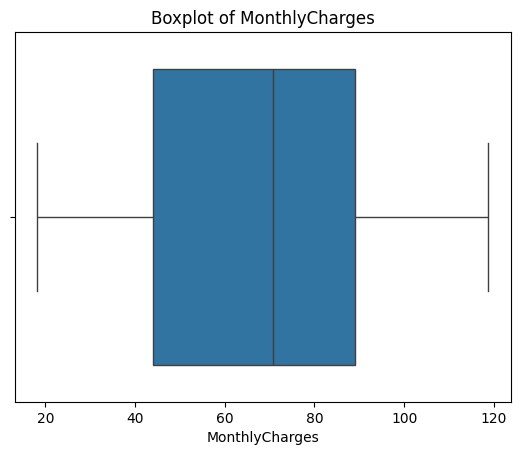

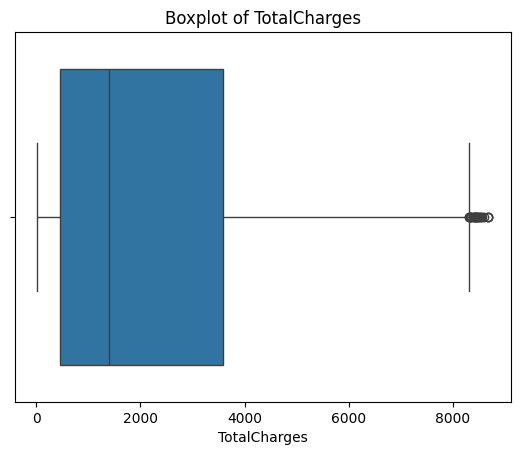

In [ ]:
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
df['SeniorCitizen'].value_counts()

,count
SeniorCitizen,
0,4734
1,900


In [ ]:
df['TotalCharges'].value_counts()

,count
TotalCharges,
1396.45,290
19.65,8
20.20,8
19.90,7
19.75,7
...,...
5311.85,1
342.30,1
1313.55,1


In [ ]:
y = df['Churn']

X = df.drop(['Churn'], axis=1)

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

print('\nX head:')
display(X.head())
print('\ny head:')
display(y.head())

Shape of X: (5634, 30)
Shape of y: (5634,)

X head:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,StreamingMovies_No internet service,...,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes
0,1,0,0,0,35,1,0,20.75,700.45,1,...,1,0,1,0,1,0,1,0,1,0
1,1,0,0,0,28,0,1,35.75,961.40,0,...,0,0,0,0,0,1,0,1,0,0
2,0,0,0,0,56,1,0,98.60,5581.05,0,...,0,0,0,1,0,0,0,0,0,1
3,0,0,1,0,39,1,1,20.45,790.00,1,...,1,0,1,0,1,0,1,0,1,0
4,1,0,1,1,43,0,1,51.25,2151.60,0,...,0,0,0,1,0,0,0,1,0,1



y head:


,Churn
0,1
1,1
2,1
3,1
4,1


In [ ]:
from sklearn.model_selection import train_test_split

Train-Test splitting

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
for col in X_train.select_dtypes(include='object').columns:
    print(f"Value counts for column '{col}':")
    display(X_train[col].value_counts())
    print('\n' + '='*50 + '\n') # Separator for better readability

Value counts for column 'customerID':


,count
customerID,
4710-FDUIZ,1
7550-WIQVA,1
0423-UDIJQ,1
0329-GTIAJ,1
3982-JGSFD,1
...,...
7392-YYPYJ,1
5199-FPUSP,1
1987-AUELQ,1




Value counts for column 'gender':


,count
gender,
Male,2366
Female,2141




Value counts for column 'Partner':


...

,count
Contract,
Month-to-month,2453
Two year,1093
One year,961




Value counts for column 'PaperlessBilling':


,count
PaperlessBilling,
Yes,2670
No,1837




Value counts for column 'PaymentMethod':


,count
PaymentMethod,
Electronic check,1474
Mailed check,1052
Bank transfer (automatic),1009
Credit card (automatic),972


In [ ]:
#Encoding the target

In [ ]:
df['Churn'] = df['Churn'].map({
    'Yes': 0,
    'No': 1
})

In [ ]:
df['Churn'].value_counts()

,count
Churn,
1,4130
0,1504


In [ ]:
#encoding the features

In [ ]:
df['Partner'].value_counts()

,count
Partner,
No,2890
Yes,2744


In [ ]:
df['Dependents'].value_counts()

,count
Dependents,
No,3960
Yes,1674


In [ ]:
columns = ['customerID','gender',    'SeniorCitizen',    'Partner',    'Dependents',    'tenure',    'PhoneService',    'MultipleLines'    ,'InternetService'    ,'OnlineSecurity',    'DeviceProtection',    'TechSupport',    'StreamingTV'    ,'StreamingMovies'    ,'Contract',    'PaperlessBilling',    'PaymentMethod',    'MonthlyCharges'    ,'TotalCharges']

for col in columns:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for customerID:
customerID
3402-XRIUO    1
9509-MPYOD    1
3082-VQXNH    1
8190-ZTQFB    1
1258-YMZNM    1
             ..
4697-LUPSU    1
7048-GXDAY    1
6682-VCIXC    1
4884-LEVMQ    1
2208-UGTGR    1
Name: count, Length: 5634, dtype: int64

Value counts for gender:
gender
Male      2913
Female    2721
Name: count, dtype: int64

Value counts for SeniorCitizen:
SeniorCitizen
0    4734
1     900
Name: count, dtype: int64

Value counts for Partner:
Partner
No     2890
Yes    2744
Name: count, dtype: int64

Value counts for Dependents:
Dependents
No     3960
Yes    1674
Name: count, dtype: int64

Value counts for tenure:
tenure
1     474
72    302
2     188
3     154
4     141
     ... 
28     45
36     44
44     43
39     42
0       9
Name: count, Length: 73, dtype: int64

Value counts for PhoneService:
PhoneService
Yes    5081
No      553
Name: count, dtype: int64

Value counts for MultipleLines:
MultipleLines
No                  2701
Yes                 2380
No phone ser

In [ ]:
# List of binary columns with 'Yes' and 'No' values
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'
]

# Map 'Yes' -> 1 and 'No' -> 0
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [ ]:
# List of columns to one-hot encode
ohe_cols = ['StreamingMovies', 'Contract', 'PaymentMethod']

# Apply One-Hot Encoding and convert boolean values to 0/1 integers
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

In [ ]:
df['gender'] = df['gender'].map({
    'Male': 0,
    'Female': 1
})


In [ ]:
unencoded_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Remaining unencoded categorical columns:", unencoded_cols)

Remaining unencoded categorical columns: ['customerID', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV']


In [ ]:
# Drop customerID if it is present in the DataFrame
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Select all remaining categorical columns
remaining_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Apply One-Hot Encoding to all remaining categorical columns
if remaining_cols:
    df = pd.get_dummies(df, columns=remaining_cols, drop_first=True, dtype=int)
    print("Successfully encoded:", remaining_cols)
else:
    print("All categorical columns are already encoded!")

Successfully encoded: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV']


In [ ]:
#Scaling

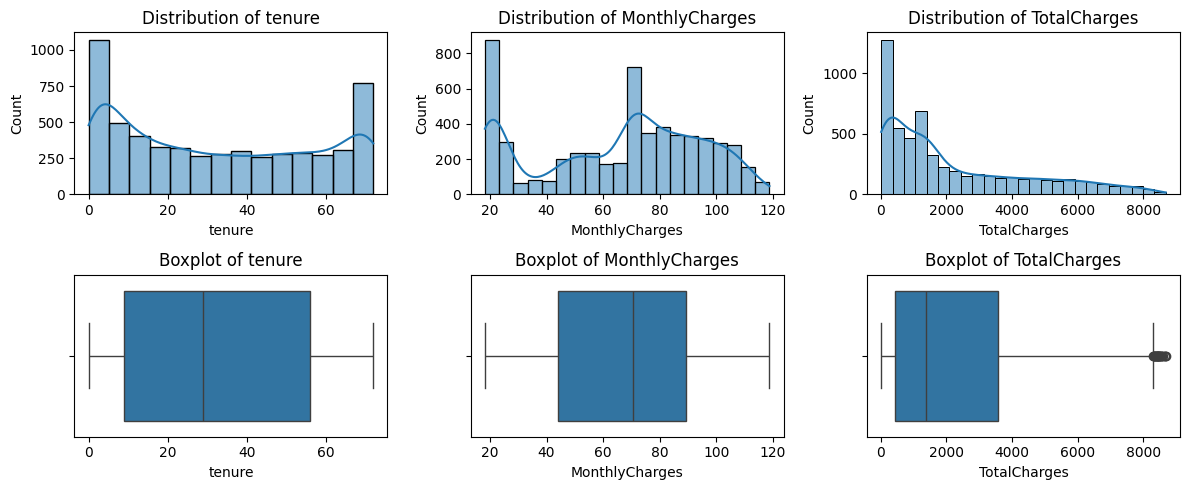

In [ ]:


# Numerical columns to scale
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Check distributions and outliers
plt.figure(figsize=(12, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(2, 3, i+3)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
#scailing the data
num_col = ['TotalCharges','tenure','MonthlyCharges']

from sklearn.preprocessing import MinMaxScaler

scalar = MinMaxScaler()

#Scale numerical columns for x_train
X_train[num_col] = scalar.fit_transform(X_train[num_col])

#Scale numerical columns for x_test
X_test[num_col] = scalar.transform(X_test[num_col])
#feature engineering
X_train['CLV_Estimated'] = X_train['tenure'] * X_train['MonthlyCharges']
X_test['CLV_Estimated'] = X_test['tenure'] * X_test['MonthlyCharges']

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
models = {

    'Logistic Regression':
        LogisticRegression(max_iter=1000),

    'KNN':
        KNeighborsClassifier(n_neighbors=5),

    'Naive Bayes':
        GaussianNB(),

    'Decision Tree':
        DecisionTreeClassifier(random_state=42),

    'Random Forest':
        RandomForestClassifier(random_state=42),

    'SVM':
        SVC()
}

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Split training set into train and validation sets
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 2. Handle class imbalance on training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_tr, y_tr)

# 3. Assign selected feature sets (or use all features)
X_train_selected = X_train_balanced
X_val_selected = X_val

In [ ]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():

    model.fit(
        X_train_selected,
        y_train_balanced
    )

    y_pred = model.predict(X_val_selected)

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    results[name] = accuracy

    print(
        name,
        "Accuracy:",
        round(accuracy, 4)
    )

Logistic Regression Accuracy: 0.7373
KNN Accuracy: 0.6918
Naive Bayes Accuracy: 0.7184
Decision Tree Accuracy: 0.6851
Random Forest Accuracy: 0.7406
SVM Accuracy: 0.7384


In [ ]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=['Model', 'Accuracy']
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy
4,Random Forest,0.740576
5,SVM,0.738359
0,Logistic Regression,0.737251
2,Naive Bayes,0.718404
1,KNN,0.691796
3,Decision Tree,0.685144


select best model

In [ ]:
best_model_name = results_df.iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: Random Forest


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [ ]:
grid_search.fit(
    X_train_selected,
    y_train_balanced
)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
best_grid_model = grid_search.best_estimator_

print(best_grid_model)

RandomForestClassifier(n_estimators=200, random_state=42)


In [ ]:
print("Best CV Score:")
print(grid_search.best_score_)

Best CV Score:
0.8383188501179463


In [ ]:
model.fit(
    X_train_selected,
    y_train_balanced
)

before_tuning = accuracy_score(
    y_val,
    model.predict(X_val_selected)
)

print("Before GridSearch:", before_tuning)

Before GridSearch: 0.738359201773836


In [ ]:
after_tuning = accuracy_score(
    y_val,
    best_grid_model.predict(X_val_selected)
)

print("After GridSearch:", after_tuning)

After GridSearch: 0.7427937915742794


In [ ]:
print("Improvement:",
      after_tuning - before_tuning)

Improvement: 0.0044345898004434225


using test data

In [ ]:
import pandas as pd

# Upload / load new test dataset
new_test = pd.read_csv("/content/Testing_data.csv")

# Check data
new_test.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [ ]:
new_test.shape

(1409, 21)

In [ ]:
new_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [ ]:
new_test.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
test_df['CustomerLifetimeValue'] = test_df['tenure'] * test_df['MonthlyCharges']

In [ ]:
new_test['CustomerLifetimeValue'] = (
    new_test['tenure'] * new_test['MonthlyCharges']
)

In [ ]:
if 'Churn' in new_test.columns:
    new_test = new_test.drop('Churn', axis=1)

In [ ]:
new_test = pd.get_dummies(new_test, drop_first=True)

In [ ]:
new_test = new_test.reindex(columns=X.columns, fill_value=0)

In [ ]:
print("Training columns:", len(X.columns))
print("New test columns:", len(new_test.columns))

Training columns: 30
New test columns: 30


In [ ]:
new_test = new_test.astype(float)

In [ ]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)

In [ ]:
scaler.fit_transform(new_test)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
X_new_test_scaled = scaler.transform(new_test)

In [ ]:
# 1. Prepare test feature set
X_new_test_scaled = test_df.copy()

# 2. Get the best model from GridSearch
best_model = grid_search.best_estimator_



In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Initialize scaler, PCA, and selector
scaler = MinMaxScaler()
pca = PCA(n_components=10)  # adjust n_components as needed
selector = SelectKBest(score_func=f_classif, k=5)  # adjust k as needed

# 2. Fit and transform
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_train_pca = pca.fit_transform(X_train_scaled)
X_train_selected = selector.fit_transform(X_train_pca, y_train_balanced)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train_balanced)

X_train_pca = pca.fit_transform(X_train_scaled)

X_train_selected = selector.fit_transform(
    X_train_pca,
    y_train_balanced
)

In [ ]:
import pandas as pd

# 1. Load test dataset
new_test = pd.read_csv('/content/Testing_data.csv')

# Save customerID for the final output table
if 'customerID' in new_test.columns:
    customer_ids = new_test['customerID']
    new_test = new_test.drop(columns=['customerID'])

# 2. Impute missing values prior to encoding
if 'MonthlyCharges' in new_test.columns:
    new_test['MonthlyCharges'] = new_test['MonthlyCharges'].fillna(df['MonthlyCharges'].median())
if 'TotalCharges' in new_test.columns:
    new_test['TotalCharges'] = pd.to_numeric(new_test['TotalCharges'], errors='coerce')
    new_test['TotalCharges'] = new_test['TotalCharges'].fillna(df['TotalCharges'].median())

for col in ['gender', 'OnlineSecurity']:
    if col in new_test.columns and new_test[col].isnull().sum() > 0:
        new_test[col] = new_test[col].fillna(df[col].mode()[0])

# 3. Apply binary mapping
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in new_test.columns:
        new_test[col] = new_test[col].map({'Yes': 1, 'No': 0})

if 'gender' in new_test.columns:
    new_test['gender'] = new_test['gender'].map({'Male': 0, 'Female': 1})

# 4. One-Hot Encoding
new_test = pd.get_dummies(new_test, drop_first=True, dtype=int)

# 5. Scale numerical columns
num_col = ['TotalCharges', 'tenure', 'MonthlyCharges']
new_test[num_col] = scalar.transform(new_test[num_col])

# 6. Align columns to match the exact feature names/order used when fitting PCA
if hasattr(pca_applied, 'feature_names_in_'):
    new_test = new_test.reindex(columns=pca_applied.feature_names_in_, fill_value=0)

# 7. Apply PCA transformation
new_test_pca = pca_applied.transform(new_test)

# 8. Predict using the trained model
y_new_test_pred = best_grid_model.predict(new_test_pca)

# 9. Map predictions back to original labels (Yes/No)
prediction_labels = ['Yes' if p == 1 else 'No' for p in y_new_test_pred]

# 10. Create and view result DataFrame
prediction_result = pd.DataFrame({
    'CustomerID': customer_ids if 'customer_ids' in locals() else new_test.index,
    'Predicted_Churn': prediction_labels
})

display(prediction_result.head())

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,CustomerID,Predicted_Churn
0,6080-TCMYC,Yes
1,7285-KLOTR,Yes
2,7486-KSRVI,Yes
3,9924-JPRMC,Yes
4,4439-YRNVD,Yes


In [ ]:
import pandas as pd

# 1. Load test dataset
new_test = pd.read_csv('/content/Testing_data.csv')

# Save customerID for the final output table
if 'customerID' in new_test.columns:
    customer_ids = new_test['customerID']
    new_test = new_test.drop(columns=['customerID'])

# 2. Impute missing values prior to encoding
if 'MonthlyCharges' in new_test.columns:
    new_test['MonthlyCharges'] = new_test['MonthlyCharges'].fillna(df['MonthlyCharges'].median())
if 'TotalCharges' in new_test.columns:
    new_test['TotalCharges'] = pd.to_numeric(new_test['TotalCharges'], errors='coerce')
    new_test['TotalCharges'] = new_test['TotalCharges'].fillna(df['TotalCharges'].median())

for col in ['gender', 'OnlineSecurity']:
    if col in new_test.columns and new_test[col].isnull().sum() > 0:
        new_test[col] = new_test[col].fillna(df[col].mode()[0])

# 3. Apply binary mapping
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    if col in new_test.columns:
        new_test[col] = new_test[col].map({'Yes': 1, 'No': 0})

if 'gender' in new_test.columns:
    new_test['gender'] = new_test['gender'].map({'Male': 0, 'Female': 1})

# 4. One-Hot Encoding
new_test = pd.get_dummies(new_test, drop_first=True, dtype=int)

# 5. Scale numerical columns
num_col = ['TotalCharges', 'tenure', 'MonthlyCharges']
new_test[num_col] = scalar.transform(new_test[num_col])

# 6. Align columns to match the exact feature names/order used when fitting PCA
if hasattr(pca_applied, 'feature_names_in_'):
    new_test = new_test.reindex(columns=pca_applied.feature_names_in_, fill_value=0)

# 7. Apply PCA transformation
new_test_pca = pca_applied.transform(new_test)

# 8. Predict using the trained model
y_new_test_pred = best_grid_model.predict(new_test_pca)

# 9. Map predictions back to original labels (Yes/No)
prediction_labels = ['Yes' if p == 1 else 'No' for p in y_new_test_pred]

# 10. Create and view result DataFrame
prediction_result = pd.DataFrame({
    'CustomerID': customer_ids if 'customer_ids' in locals() else new_test.index,
    'Predicted_Churn': prediction_labels
})

display(prediction_result.head())

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


,CustomerID,Predicted_Churn
0,6080-TCMYC,Yes
1,7285-KLOTR,Yes
2,7486-KSRVI,Yes
3,9924-JPRMC,Yes
4,4439-YRNVD,Yes
